# Clustering Untuk Menentukan Karakteristik Serta Tipe Eksoplanet

## Dataset NASA Exoplanet Archive

Dataset **NASA Exoplanet Archive** berisi informasi mengenai karakteristik fisik dan orbital planet-planet di luar tata surya kita, seperti massa, radius, periode orbit, dan temperatur kesetimbangan, beserta properti bintang induknya. Keragaman serta rentang nilai yang sangat luas pada parameter-parameter astrofisika ini menyebabkan para peneliti perlu memahami pola alami serta taksonomi kelompok planet yang memiliki kesamaan morfologi fisik.

Dataset ini didapatkan bersumber dari: _http://exoplanetarchive.ipac.caltech.edu_

Salah satu pendekatan yang dapat digunakan adalah Unsupervised Learning, khususnya clustering. Dengan clustering, eksoplanet dapat dikelompokkan secara otomatis berdasarkan kemiripan struktur fisis dan dinamika orbitnya (seperti kandidat planet gas raksasa, planet es, hingga planet berbatu mirip Bumi) tanpa memerlukan label klasifikasi sebelumnya.

In [3]:
# Import Library yang dibutuhkan

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [8]:
# Baca Dataset
df = pd.read_csv("all_exoplanets_2021.csv")
df.head()

,No.,Planet Name,Planet Host,Num Stars,Num Planets,Discovery Method,Discovery Year,Discovery Facility,Orbital Period Days,Orbit Semi-Major Axis,Mass,Eccentricity,Insolation Flux,Equilibrium Temperature,Spectral Type,Stellar Effective Temperature,Stellar Radius,Stellar Mass,Stellar Metallicity,Stellar Metallicity Ratio,Stellar Surface Gravity,Distance,Gaia Magnitude
0,1,11 Com b,11 Com,2,1,Radial Velocity,2007,Xinglong Station,326.030,1.290,6165.600,0.231,NaN,NaN,G8 III,4742.000,19.000,2.700,-0.350,[Fe/H],2.310,93.185,4.440
1,2,11 UMi b,11 UMi,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,516.220,1.530,4684.814,0.080,NaN,NaN,NaN,4213.000,29.790,2.780,-0.020,[Fe/H],1.930,125.321,4.562
2,3,14 And b,14 And,1,1,Radial Velocity,2008,Okayama Astrophysical Observatory,185.840,0.830,1525.500,0.000,NaN,NaN,K0 III,4813.000,11.000,2.200,-0.240,[Fe/H],2.630,75.439,4.918
3,4,14 Her b,14 Her,1,2,Radial Velocity,2002,W. M. Keck Observatory,1773.400,2.930,1481.088,0.370,NaN,NaN,NaN,5338.000,0.930,0.900,0.410,[Fe/H],4.450,17.932,6.383
4,5,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996,Multiple Observatories,798.500,1.660,565.737,0.680,NaN,NaN,NaN,5750.000,1.130,1.080,0.060,[Fe/H],4.360,21.140,6.064


In [10]:
# Melihat bentuk dataset

df.shape

(4575, 23)

In [11]:
# Tampilkan informasi struktur DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4575 entries, 0 to 4574
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   No.                            4575 non-null   int64  
 1   Planet Name                    4575 non-null   object 
 2   Planet Host                    4575 non-null   object 
 3   Num Stars                      4575 non-null   int64  
 4   Num Planets                    4575 non-null   int64  
 5   Discovery Method               4575 non-null   object 
 6   Discovery Year                 4575 non-null   int64  
 7   Discovery Facility             4575 non-null   object 
 8   Orbital Period Days            4413 non-null   float64
 9   Orbit Semi-Major Axis          2763 non-null   float64
 10  Mass                           2006 non-null   float64
 11  Eccentricity                   1707 non-null   float64
 12  Insolation Flux                370 non-null    f

In [12]:
# Tampilkan statistik deskriptif dari dataset
df.describe()

,No.,Num Stars,Num Planets,Discovery Year,Orbital Period Days,Orbit Semi-Major Axis,Mass,Eccentricity,Insolation Flux,Equilibrium Temperature,Stellar Effective Temperature,Stellar Radius,Stellar Mass,Stellar Metallicity,Stellar Surface Gravity,Distance,Gaia Magnitude
count,4575.000,4575.000,4575.000,4575.000,4413.000,2763.000,2006.000,1707.000,370.000,925.000,4226.000,4128.000,3844.000,3204.000,3972.000,4471.000,4400.000
mean,2288.000,1.110,1.788,2014.863,94899.322,10.940,725.124,0.155,446.658,1057.812,5439.167,1.535,0.973,0.013,4.364,656.376,12.432
std,1320.833,0.352,1.167,3.961,6053595.477,182.399,1338.017,0.183,2456.276,561.188,1420.268,3.818,0.474,0.180,0.431,938.408,2.993
min,1.000,1.000,1.000,1989.000,0.091,0.004,0.020,0.000,0.060,50.000,575.000,0.010,0.010,-1.000,1.200,1.301,2.926
25%,1144.500,1.000,1.000,2014.000,4.438,0.056,16.148,0.014,5.710,619.000,4989.250,0.790,0.790,-0.070,4.290,123.739,10.750
50%,2288.000,1.000,1.000,2016.000,11.763,0.115,220.887,0.092,45.700,961.000,5574.000,0.960,0.960,0.020,4.450,434.754,13.359
75%,3431.500,1.000,2.000,2016.000,41.008,0.679,740.535,0.220,226.525,1457.000,5908.000,1.250,1.110,0.110,4.560,856.417,14.780
max,4575.000,4.000,8.000,2021.000,402000000.000,7506.000,17668.170,0.950,44900.000,4050.000,40000.000,83.800,10.940,0.545,7.920,8200.000,20.186


#### **Analisis Singkat:**

Dataset **Nasa Exoplanet Archive** ini memiliki 4.575 entri eksoplanet dengan 23 feature yang mencakup karakteristik orbital, parameter fisis planet, serta atribut bintang induknya yang ditemukan antara tahum 1989 hingga 2021. Berdasarkan statistik dan struktur data pada dataset ini, parameter kunci seperti massa dengan rata-rata 725,12 unit masa Bumi/jupiter, dengan median 220,89 dan periode orbit menunjukan bahwa dispersi serta rentang nilai yang sangat ekstem, ditandai oleh selisih nilai maksimum dan kuartil yang sangat masif. 

Selain itu, pada dataset ini juga terdapat variasi kelengkapan data yang signifikan antar fitur. kelengkapan ini diantara lainnya didapatkan dari fitur orbit dan posisi bintang yang relatif lengkap. Sementara itu fitur termal seperti _Equilibrium Temperature_ (925 non-null) dan _Insolation Flux_ (370 non-null) memiliki banyak nilai yang hilang.

## Bussiness Understanding

**Latar Belakang:**
Katalog *NASA Exoplanet Archive* menyimpan ribuan data observasi eksoplanet dengan berbagai parameter astrofisika yang kompleks (massa, periode orbit, jarak sumbu semi-mayor, temperatur, dan atribut bintang induk). Hingga saat ini, data observasi tersebut tidak memiliki label kelas standar (*unlabeled data*), sehingga memerlukan klasifikasi otomatis untuk mengorganisasi dan memahami keberagaman populasi planet di luar tata surya.

**Tujuan Analisis (Objective):**
1. **Membangun Taksonomi Otomatis:** Mengidentifikasi klaster atau kelompok alami eksoplanet berdasarkan kesamaan karakteristik fisik dan dinamika orbit menggunakan algoritma unsupervised clustering (seperti K-Means).
2. **Karakterisasi Populasi Planet:** Memisahkan kelompok planet ke dalam kategori morfologi alami, seperti *Hot Jupiters*, planet raksasa dingin (*Cold Gas Giants*), serta kandidat planet berbatu (*rocky / terrestrial planets*).
3. **Prioritisasi Riset Astronomi:** Memberikan dasar segmentasi data yang terstruktur bagi astronom untuk menentukan kandidat planet prioritas dalam studi lanjutan (misalnya observasi spektroskopi atmosfer atau pencarian zona laik huni).

## Alasan kenapa dataset tersebut bisa digunakan clustering

Dataset *NASA Exoplanet Archive* ini sangat layak dan ideal untuk pemodelan clustering berdasarkan karakteristik data yang telah dianalisis sebelumnya:

1. **Sifat Data Tanpa Label (*Unlabeled Data*):**

2. **Dominasi Fitur Kontinu / Numerik:**

3. **Multimodalitas dan Variansi yang Luas (*High Variance & Skewness*):**

4. **Kebutuhan Taksonomi Alami Berdasarkan Multivariat:**

## Data Understanding

### EDA _(Exploration Data Analyst)_

In [15]:
# Import library matplotlib dan seaborn untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

kita akan melakukan eksplorasi awal dengan melihat hubungan antara variabel `Stellar Mass` dengan `Mass`

Hal ini dilakukan untuk memahami korelasi antara ukuran bintang induk dan planet yang terbentuk di sekitarnya.

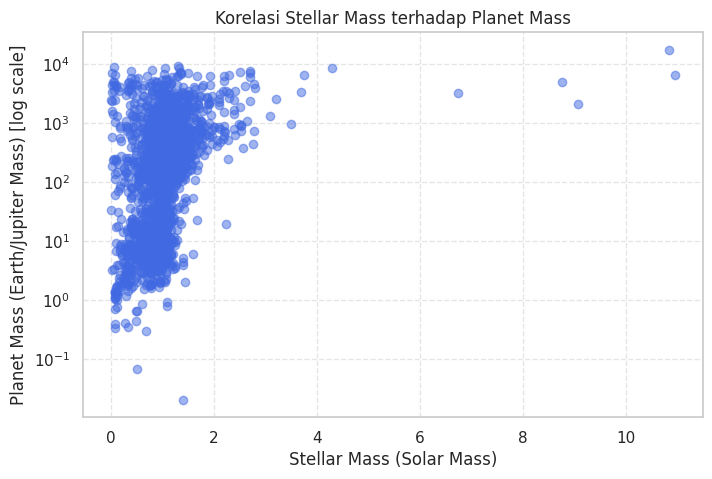

In [20]:
df_scatter = df[
    ['Stellar Mass', 
     'Mass'
    ]].dropna()

plt.figure(figsize=(8, 5))
plt.scatter(df_scatter['Stellar Mass'],
            df_scatter['Mass'],
            alpha=0.5,
            color='royalblue')

plt.yscale('log')

plt.xlabel('Stellar Mass (Solar Mass)')
plt.ylabel('Planet Mass (Earth/Jupiter Mass) [log scale]')
plt.title('Korelasi Stellar Mass terhadap Planet Mass')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

dari grafik korelasi diatas ditemukan bahwa sebagian besar eksoplanet yang ditemukan mengitari bintang yang berukurannya mirip dengan Matahari. Pada kelompok bintang tersebut, jenis planet yang terdeteksi sangat beragam, mulai dari planet berukuran kecil yang mirip Bumi hingga raksasa gas sekelas Jupiter, yang terlihat jelas dari sebaran titik data yang memanjang dari bawah ke atas.

## Data Preparation
Tahap ini bertujuan untuk menyiapkan data agar siap digunakan oleh algoritma clustering, meliputi seleksi fitur relevan, penanganan missing values, transformasi logaritmik, dan standarisasi fitur.

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
# 1. Seleksi fitur utama yang merepresentasikan karakteristik planet
selected_features = ['Orbital Period Days', 'Orbit Semi-Major Axis', 'Mass']
df_prep = df[selected_features].dropna().copy()

# 2. Transformasi logaritmik untuk mengatasi rentang nilai yang ekstrem (skewness)
df_log = np.log1p(df_prep)

# 3. Standarisasi fitur dengan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log)

print("Jumlah data setelah dibersihkan:", X_scaled.shape[0])
print("Bentuk fitur siap latih:", X_scaled.shape)

Jumlah data setelah dibersihkan: 1555
Bentuk fitur siap latih: (1555, 3)


## Modeling

Pada modeling kita menggunakan algoritma K-Means Clustering. Algoritma ini digunakan karena seluruh fitur yang telah dipersiapkan (`Orbital Period Days`, `Orbit Semi-Major Axis`, dan `Mass`) bertipe numerik kontinu dan sudah di standarisasi. 

In [26]:
# Tentukan jumlah cluster menggunakan Elbow Method
from sklearn.cluster import KMeans

inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)  # Gunakan X_scaled
    inertia.append(kmeans.inertia_)

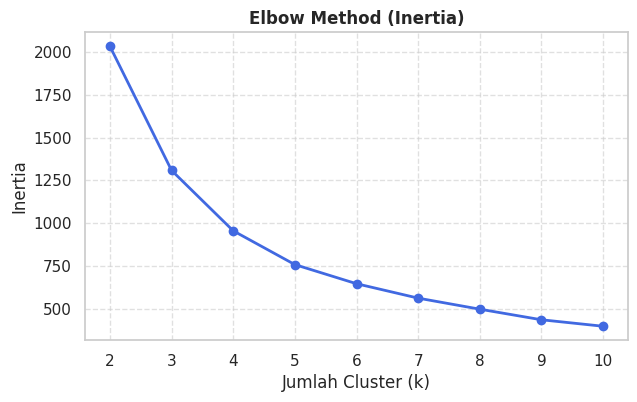

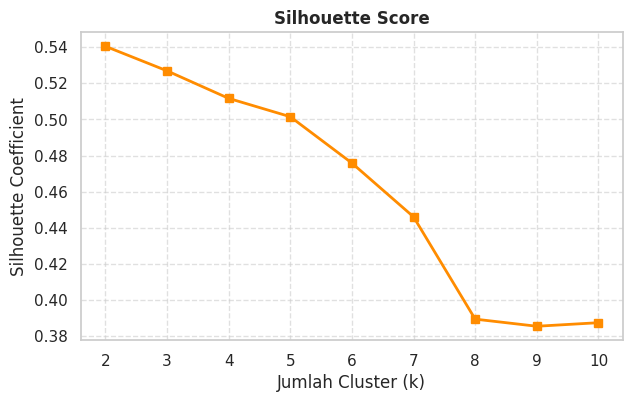

In [35]:
from sklearn.metrics import silhouette_score

# Hitung silhouette score untuk tiap k
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# 1. Grafik Elbow Method
plt.figure(figsize=(7, 4))
plt.plot(range(2, 11), inertia, marker='o', color='royalblue', linewidth=2)
plt.title('Elbow Method (Inertia)', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Grafik Silhouette Score
plt.figure(figsize=(7, 4))
plt.plot(range(2, 11), silhouette_scores, marker='s', color='darkorange', linewidth=2)
plt.title('Silhouette Score', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Coefficient')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Berdasarkan grafik Elbow Method dan Silhouette Score di atas, kita dapat memilih **k = 3** (atau nilai k dengan siku tertajam dan skor silhouette optimal) sebagai jumlah klaster alami eksoplanet. Selanjutnya kita melatih model final dengan k tersebut dan memasukkan label klaster ke dalam dataframe asli.

In [32]:
# Pelatihan model final dengan k=3
k_optimal = 3
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_prep['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Tampilkan jumlah anggota tiap klaster
print("Distribusi jumlah planet per klaster:")
print(df_prep['Cluster'].value_counts())

Distribusi jumlah planet per klaster:
Cluster
0    533
1    526
2    496
Name: count, dtype: int64


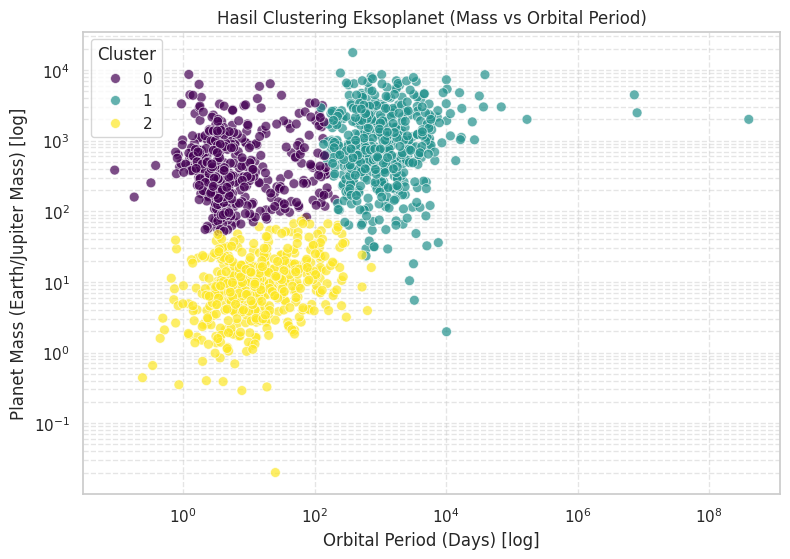

In [33]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_prep,
    x='Orbital Period Days',
    y='Mass',
    hue='Cluster',
    palette='viridis',
    alpha=0.7,
    s=50
)
plt.xscale('log')
plt.yscale('log')
plt.title('Hasil Clustering Eksoplanet (Mass vs Orbital Period)')
plt.xlabel('Orbital Period (Days) [log]')
plt.ylabel('Planet Mass (Earth/Jupiter Mass) [log]')
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(title='Cluster')
plt.show()

In [34]:
# Profiling karakteristik tiap klaster (median dan mean)
cluster_profile = df_prep.groupby('Cluster').agg(['median', 'mean'])
cluster_profile

Orbital Period Days            Orbit Semi-Major Axis           Mass  \
                     median       mean                median   mean  median   
Cluster                                                                       
0                     3.979     16.350                 0.051  0.099 309.566   
1                   918.769 795863.141                 1.970 17.984 772.327   
2                    13.217     37.141                 0.096  0.160   8.825   

                  
            mean  
Cluster           
0        619.799  
1       1445.428  
2         13.106

## Kesimpulan dan Interpretasi Hasil Modeling

Berdasarkan seluruh tahapan modeling menggunakan algoritma **K-Means Clustering** ($k = 3$) terhadap 1.555 data eksoplanet bersih, model berhasil mempartisi populasi planet ke dalam tiga kelompok alami yang sangat seimbang dan memiliki profil fisis yang khas:

1. **Klaster 0 — *Hot Jupiters* (Raksasa Gas Dekat Bintang) — 533 Planet:**
   * **Karakteristik:** Memiliki massa yang sangat masif (median ~309,57 $M_{\oplus}$, setara ukuran Jupiter) dengan orbit yang luar biasa dekat ke bintang induknya (median jarak 0,051 AU) dan periode revolusi sangat singkat (median ~3,98 hari).
   * **Interpretasi Astrofisika:** Kelompok ini mewakili kategori planet gas raksasa bersuhu tinggi yang mengorbit bintangnya dalam hitungan hari.

2. **Klaster 1 — *Cold Gas Giants* (Raksasa Gas Dingin / Orbit Lebar) — 526 Planet:**
   * **Karakteristik:** Merupakan kelompok planet paling masif (median ~772,33 $M_{\oplus}$) dengan periode orbit yang sangat panjang (median ~918,77 hari atau sekitar 2,5 tahun Bumi) serta jarak orbit yang lebar (median 1,97 AU).
   * **Interpretasi Astrofisika:** Merepresentasikan raksasa gas dingin di orbit luar, serupa dengan posisi Jupiter dan Saturnus pada tata surya kita.

3. **Klaster 2 — *Terrestrial & Super-Earths* (Planet Batuan / Ukuran Kecil) — 496 Planet:**
   * **Karakteristik:** Memiliki massa yang paling rendah (median ~8,83 $M_{\oplus}$ dan rata-rata 13,11 $M_{\oplus}$) dengan jarak orbit moderat (median 0,096 AU) serta periode orbit singkat-menengah (median ~13,22 hari).
   * **Interpretasi Astrofisika:** Kelompok ini mencakup kategori kandidat planet berbatu (*rocky planets*) dan transisi Super-Bumi/Mini-Neptunus. Kelompok inilah yang menjadi fokus utama dalam riset astrobiologi untuk pencarian planet layak huni.

### Kesimpulan Akhir
Penerapan *K-Means* yang diawali transformasi logaritmik dan standarisasi berhasil menjawab objektif *Business Understanding*, yaitu menyusun taksonomi alami eksoplanet secara otomatis tanpa label awal (*unsupervised*). Model membuktikan bahwa variasi populasi eksoplanet terpisah secara tegas berdasarkan dinamika interaksi antara massa planet dan jarak/periode orbitnya.

## Evaluasi

In [36]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Ambil label klaster dari hasil model k=3
labels = df_prep['Cluster']

# 1. Hitung metrik evaluasi
sil_score = silhouette_score(X_scaled, labels)
db_score = davies_bouldin_score(X_scaled, labels)
ch_score = calinski_harabasz_score(X_scaled, labels)

# 2. Tampilkan hasil evaluasi
print("=== HASIL EVALUASI CLUSTERING K-MEANS (k = 3) ===")
print(f"Silhouette Score          : {sil_score:.4f}")
print(f"Davies-Bouldin Index      : {db_score:.4f}")
print(f"Calinski-Harabasz Index   : {ch_score:.4f}")

=== HASIL EVALUASI CLUSTERING K-MEANS (k = 3) ===
Silhouette Score          : 0.5270
Davies-Bouldin Index      : 0.6361
Calinski-Harabasz Index   : 1991.4695


### Interpretasi Metrik Evaluasi:
1. **Silhouette Score:** Mengukur seberapa mirip suatu objek dengan klasternya sendiri dibandingkan dengan klaster lain (rentang -1 hingga 1). Nilai positif menunjukkan batas antar-klaster terpisah secara baik.
2. **Davies-Bouldin Index:** Mengukur rasio kesamaan dalam klaster dengan jarak antar-klaster. Semakin **rendah** nilainya (mendekati 0), semakin kompak dan terpisah klaster yang terbentuk.
3. **Calinski-Harabasz Index:** Mengukur rasio dispersi antar-klaster terhadap dispersi intra-klaster. Semakin **tinggi** nilainya, semakin baik dan padat struktur partisi klaster.